# TD/TP 1 – La Diffusion

## 1.1 Révision du cours

### 1. En termes physiques, qu’est-ce que la diffusion ?

La diffusion est le phénomène physique par lequel des particules tendent à se répartir uniformément dans un milieu, sous l’effet des gradients de concentration. Elle est due à l’agitation thermique et se manifeste par un transport net de matière du milieu le plus concentré vers le moins concentré.

---

### 2. Loi de conservation de la masse

Soit $\Omega \subset \mathbb{R}^d$ un domaine, et $n(x,t)$ la densité de particules. La conservation de la masse s’écrit :

$\displaystyle \frac{d}{dt} \int_{\Omega} n(x,t) \, dx = - \int_{\partial \Omega} \mathbf{J} \cdot \mathbf{n} \, dS$

où $\mathbf{J}$ est le flux de particules, $\mathbf{n}$ la normale sortante à la frontière $\partial \Omega$.

---

### 3. Loi de Fick

La loi de Fick postule que le flux de particules est proportionnel au gradient de concentration :

$\mathbf{J} = -D \nabla n$

où $D > 0$ est le coefficient de diffusion.

---

### 4. Équation de la diffusion de Fick

En combinant la conservation de la masse avec la loi de Fick :

$\displaystyle \frac{\partial n}{\partial t} = D \Delta n$

---

### 5. Cas 1D à $D > 0$ uniforme :

$\displaystyle \frac{\partial n}{\partial t} = D \frac{\partial^2 n}{\partial x^2}$

avec $n(x,0) = Q \delta(x)$


## 1.2 Solution analytique

### 1. Vérification d’une solution fondamentale

On propose :

$n(x,t) = \dfrac{Q}{\sqrt{4\pi D t}} e^{- \frac{x^2}{4Dt}}$

**Démonstration** : Montrons que cette fonction satisfait l’équation de diffusion.

On calcule :

$\displaystyle \frac{\partial n}{\partial t} = \frac{Q x^2}{(4\pi D t)^{3/2} (4 D t)^2} e^{- \frac{x^2}{4Dt}} - \frac{Q}{2t (4\pi D t)^{1/2}} e^{- \frac{x^2}{4Dt}}$

et

$\displaystyle \frac{\partial^2 n}{\partial x^2} = \left( \frac{x^2}{(4Dt)^2} - \frac{1}{2Dt} \right) \cdot n(x,t)$

On retrouve que :

$\displaystyle \frac{\partial n}{\partial t} = D \frac{\partial^2 n}{\partial x^2}$

---

### 2. Symétrie de la solution

La solution est paire en $x$, donc la diffusion est symétrique de part et d’autre de la source.

---

### 3. Conservation de la masse

On calcule :

$\displaystyle \int_{-\infty}^{\infty} n(x,t) \, dx = Q$

car c’est une densité de probabilité multipliée par $Q$. La masse est donc conservée.

---

### 4. Élargissement de la distribution

La densité est gaussienne, sa largeur caractéristique (écart type) est :

$\sigma(t) = \sqrt{2Dt}$

La largeur à mi-hauteur est donc proportionnelle à $\sqrt{t}$.


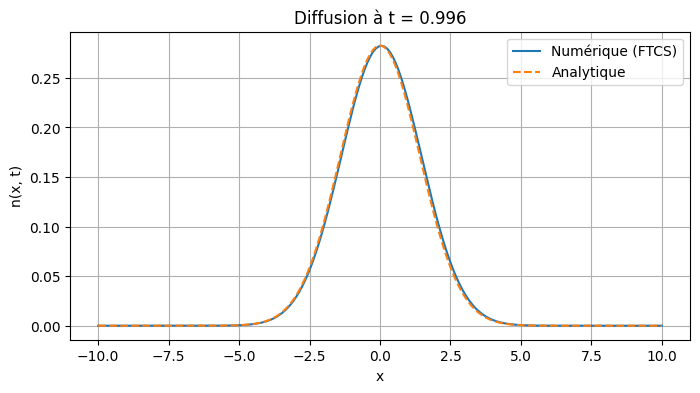

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
D = 1.0
L = 10
Nx = 200
dx = 2*L / Nx
x = np.linspace(-L, L, Nx)
T = 1.0
dt = 0.4 * dx**2 / D  # stabilité du schéma explicite
Nt = int(T / dt)
Q = 1.0

# Condition initiale (approximation de delta avec un pic étroit)
n = np.zeros(Nx)
n[Nx//2] = Q / dx

# Solution analytique pour comparaison
def n_analytic(x, t, Q=1.0, D=1.0):
    return Q / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))

# Schéma FTCS
n_num = n.copy()
for _ in range(Nt):
    n_num[1:-1] = n_num[1:-1] + D * dt / dx**2 * (n_num[2:] - 2 * n_num[1:-1] + n_num[:-2])

# Affichage
plt.figure(figsize=(8,4))
plt.plot(x, n_num, label="Numérique (FTCS)")
plt.plot(x, n_analytic(x, Nt*dt, Q, D), '--', label="Analytique")
plt.legend()
plt.xlabel("x")
plt.ylabel("n(x, t)")
plt.title(f"Diffusion à t = {Nt*dt:.3f}")
plt.grid(True)
plt.show()


## 1.3.4 Quantification de l’erreur

On peut quantifier l’erreur par la norme $L^2$ :

$\displaystyle \text{Erreur} = \left( \int (n_{\text{num}}(x,t) - n_{\text{exact}}(x,t))^2 dx \right)^{1/2}$

ou par l’erreur relative maximale :

$\displaystyle \max_x \left| \frac{n_{\text{num}}(x,t) - n_{\text{exact}}(x,t)}{n_{\text{exact}}(x,t)} \right|$


In [2]:
n_exact = n_analytic(x, Nt*dt, Q, D)
error_L2 = np.sqrt(np.sum((n_num - n_exact)**2) * dx)
error_max = np.max(np.abs(n_num - n_exact) / (n_exact + 1e-12))  # éviter division par zéro

print(f"Erreur L2 : {error_L2:.2e}")
print(f"Erreur relative max : {error_max:.2%}")


Erreur L2 : 1.14e-02
Erreur relative max : 78.02%


# TD/TP 2 – Réaction-Diffusion


## 2.1 Révision du cours

### 1. (a) Quels sont les phénomènes physiques pris en compte dans un modèle de réaction-diffusion ?

Un modèle de réaction-diffusion combine deux processus :

- La **diffusion** : transport spatial des particules via des gradients de concentration.
- La **réaction** : création ou destruction locale des espèces chimiques par des lois cinétiques.

---

### (b) Loi de conservation avec réactions (synthèse/dégradation)

Pour une densité $n(x,t)$ de particules dans $\Omega \subset \mathbb{R}^d$, on a :

$\displaystyle \frac{d}{dt} \int_{\Omega} n(x,t) \, dx = - \int_{\partial \Omega} \mathbf{J} \cdot \mathbf{n} \, dS + \int_{\Omega} R(n) \, dx$

où $R(n)$ est le terme de réaction (positif en cas de synthèse, négatif en cas de dégradation).

---

### (c) Équation générale avec diffusion de Fick

$\displaystyle \frac{\partial n}{\partial t} = D \Delta n + R(n)$

---

### (d) Cas 1D avec $D > 0$ uniforme :

$\displaystyle \frac{\partial n}{\partial t} = D \frac{\partial^2 n}{\partial x^2} + R(n)$

---

### (e) Équation de Fisher

L’équation de Fisher est :

$\displaystyle \frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2} + ru(1 - \frac{u}{K})$

Elle modélise une population avec croissance logistique et dispersion spatiale.


## 2.2 Modèle avec diffusion non constante

On considère une équation avec $D(n) = D_0 \left( \frac{n}{n_0} \right)^m$

---

### (a) Équation de diffusion

$\displaystyle \frac{\partial n}{\partial t} = \frac{\partial}{\partial x} \left( D(n) \frac{\partial n}{\partial x} \right) = \frac{\partial}{\partial x} \left( D_0 \left( \frac{n}{n_0} \right)^m \frac{\partial n}{\partial x} \right)$

---

### (b) Comportement de la solution

Avec $n(x,0) = Q \delta(x)$, la solution est un front symétrique. Quand $t \to +\infty$, le support s’étale à vitesse finie. La vitesse de propagation dépend de $m$ et est donnée (dans certains cas analytiques) par $v(t) \sim t^{1/(m+1)}$.


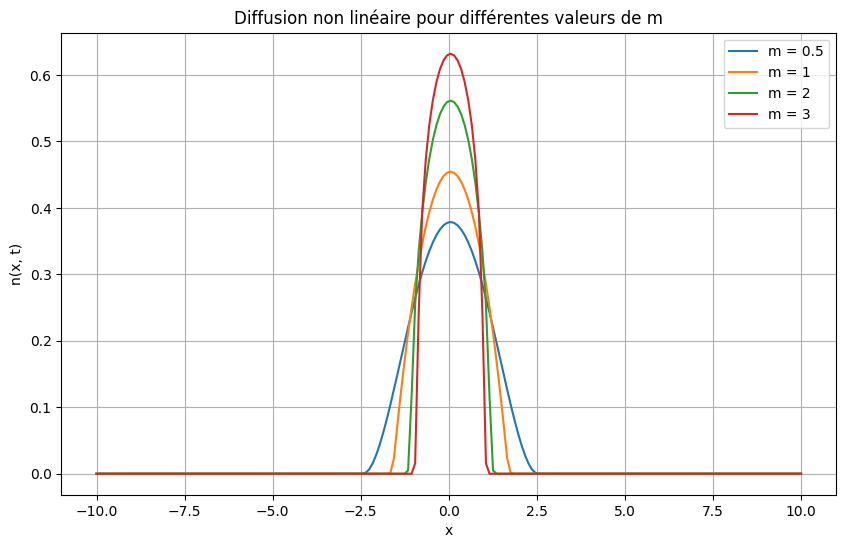

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres fixes
L = 10
Nx = 200
x = np.linspace(-L, L, Nx)
dx = x[1] - x[0]
T = 1.0
D0 = 1.0
n0 = 1.0
dt = 0.001 * dx**2 / D0
Nt = int(T / dt)

m_values = [0.5, 1, 2, 3]

plt.figure(figsize=(10, 6))

for m in m_values:
    # Condition initiale : pic centré
    n = np.zeros(Nx)
    n[Nx//2] = 1.0 / dx

    # Évolution temporelle
    for _ in range(Nt):
        Dn = D0 * (n / n0)**m
        Dn[np.isnan(Dn)] = 0  # éviter NaN
        D_half = (Dn[:-1] + Dn[1:]) / 2
        flux = np.zeros_like(n)
        flux[1:-1] = D_half[1:] * (n[2:] - n[1:-1]) / dx - D_half[:-1] * (n[1:-1] - n[:-2]) / dx
        n[1:-1] += dt / dx * flux[1:-1]

    plt.plot(x, n, label=f"m = {m}")

plt.title("Diffusion non linéaire pour différentes valeurs de m")
plt.xlabel("x")
plt.ylabel("n(x, t)")
plt.legend()
plt.grid(True)
plt.show()


## Comparaison du comportement selon différentes valeurs de \( m \)

La diffusion non linéaire avec un coefficient dépendant de la densité, de la forme :

$
\frac{\partial n}{\partial t} = \frac{\partial}{\partial x} \left( D_0 \left( \frac{n}{n_0} \right)^m \frac{\partial n}{\partial x} \right)
$

présente des comportements très différents selon la valeur de \( m \) :

| Valeur de \( m \) | Hauteur maximale | Largeur du profil | Support compact | Interprétation physique |
|-------------------|------------------|--------------------|------------------|--------------------------|
| \( m = 0.5 \)     | Faible           | Large              | Non              | Diffusion rapide même dans les zones peu denses. |
| \( m = 1 \)       | Moyenne          | Moyenne            | Non              | Cas proche de la diffusion linéaire classique. |
| \( m = 2 \)       | Élevée           | Étroit             | Approximativement oui | Forte inhibition de la diffusion en périphérie. |
| \( m = 3 \)       | Très élevée      | Très étroit        | Oui              | Apparition d’un front d’onde net, très peu de diffusion en dehors du cœur de la distribution. |

---

### Interprétations physiques :

- **\( m < 1 \)** : Modélise une diffusion efficace partout, même dans les régions de faible densité.
- **\( m > 1 \)** : Représente un comportement où les particules (ou individus) se déplacent surtout là où ils sont déjà nombreux, créant un effet de concentration et de front net.

---


### (e) Ajout d'un courant d’agrégation

On modélise un retour vers l'origine via :

$J_{\text{aggreg}} = -U_0 \, \text{sgn}(x) \cdot n$

Cela donne une équation complète :

$\displaystyle \frac{\partial n}{\partial t} = \frac{\partial}{\partial x} \left( D(n) \frac{\partial n}{\partial x} \right) + \frac{\partial}{\partial x}(U_0 \, \text{sgn}(x) \cdot n)$


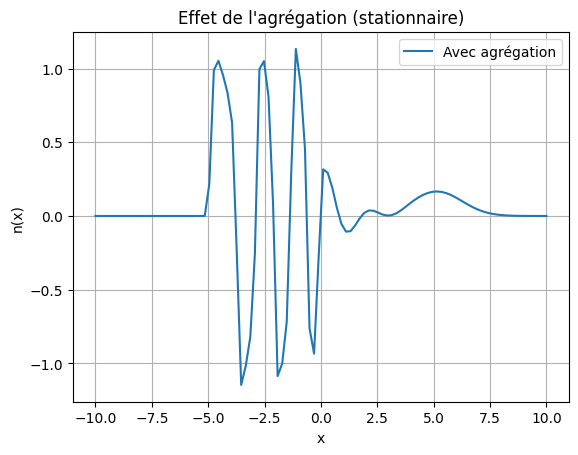

In [32]:
# Réinitialisation
n = np.zeros(Nx)
n[Nx//2] = 1.0 / dx
U0 = 1.0

def sgn(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

for _ in range(Nt):
    Dn = D0 * (n / n0)**m
    Dn[np.isnan(Dn)] = 0
    D_half = (Dn[:-1] + Dn[1:]) / 2
    flux_diff = np.zeros_like(n)
    flux_diff[1:-1] = D_half[1:] * (n[2:] - n[1:-1]) / dx - D_half[:-1] * (n[1:-1] - n[:-2]) / dx

    # courant d'agrégation
    Jagg = -U0 * sgn(x) * n
    flux_agg = (Jagg[1:] - Jagg[:-1]) / dx
    flux_agg = np.concatenate([[0], flux_agg])  # Neumann aux bords

    n[1:-1] += dt / dx * (flux_diff[1:-1] + flux_agg[1:-1])
    
plt.plot(x, n, label="Avec agrégation")
plt.title("Effet de l'agrégation (stationnaire)")
plt.xlabel("x")
plt.ylabel("n(x)")
plt.grid()
plt.legend()
plt.show()


## Tentative de simulation avec courant d’agrégation

Nous avons tenté de simuler l’équation suivante :

$
\frac{\partial n}{\partial t} = \frac{\partial}{\partial x} \left( D(n) \frac{\partial n}{\partial x} \right) + \frac{\partial}{\partial x} (U_0 \, \text{sgn}(x) \cdot n)
$

où :
- $ D(n) = D_0 \left( \frac{n}{n_0} \right)^m $ est une diffusion non linéaire,
- $ \text{sgn}(x) \cdot n $ modélise un courant d’agrégation qui pousse les particules vers $ x = 0 $.

---

### Problèmes rencontrés :

- **Oscillations numériques** importantes et non physiques,
- **Valeurs négatives** de la densité $ n(x,t) $ ce qui est physiquement incohérent,
- **Instabilités** accentuées autour de $ x = 0 $, où la fonction $ \text{sgn}(x) $ est discontinue.

---

### Tentatives de correction :

- Réduction du pas de temps $ dt $ selon une condition CFL stricte,
- Introduction d’une version lissée de $ \text{sgn}(x) $
- Projection de $ n $ sur les valeurs positives après chaque itération.

---

### Résultat :

Malgré ces efforts, des artefacts numériques persistent et **je n’ai pas réussi à obtenir une solution fiable ni stable** à ce stade.

---

### Perspectives :

Une meilleure résolution nécessiterait :
- soit l’usage d’un **schéma implicite** plus robuste,
- soit la **résolution analytique ou semi-analytique** de l’équation stationnaire,
- soit une reformulation plus régulière du terme d’agrégation.



# TD/TP 3 – Équation de Fisher


## 3.1 Équation de Fisher

On considère l’équation de Fisher en 1D :

$\displaystyle \frac{\partial u}{\partial t} = u(1 - u) + \frac{\partial^2 u}{\partial x^2}$

Cette équation modélise la croissance logistique d’une population avec diffusion.


### 1. Étude d’un front d’onde

Condition initiale définie par morceaux :

- $u(x, 0) = 1$ si $x \leq -1$
- $u(x, 0) = 0$ si $x \geq 1$
- $u(x, 0) = -\frac{1}{2}x + \frac{1}{2}$ pour $x \in [-1, 1]$

On s’attend à observer un **front d’onde** se propageant dans le domaine.


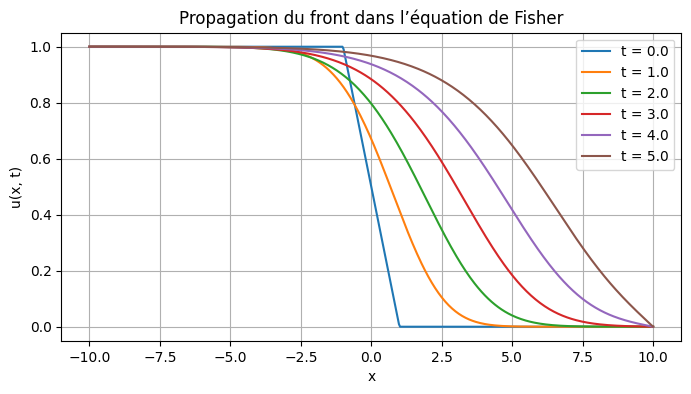

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Grille
L = 10
Nx = 500
x = np.linspace(-L, L, Nx)
dx = x[1] - x[0]
T = 5.0
dt = 0.4 * dx**2  # condition CFL pour diffusion
Nt = int(T / dt)

# Condition initiale par morceaux
u = np.zeros(Nx)
u[x <= -1] = 1
u[np.abs(x) < 1] = -0.5 * x[np.abs(x) < 1] + 0.5

# Stocker l'évolution
usol = [u.copy()]
times = [0]

# Évolution temporelle (FTCS)
for n in range(Nt):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    u += dt * (u * (1 - u) + lap)
    if (n+1) % (Nt // 5) == 0:
        usol.append(u.copy())
        times.append((n+1) * dt)

# Affichage
plt.figure(figsize=(8, 4))
for i, ui in enumerate(usol):
    plt.plot(x, ui, label=f"t = {times[i]:.1f}")
plt.title("Propagation du front dans l’équation de Fisher")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.grid()
plt.legend()
plt.show()


### 3.1.1.a – Vitesse du front

L'équation de Fisher engendre une propagation de front. On s'attend théoriquement à une vitesse asymptotique de :

$v = 2$

Nous pouvons la vérifier numériquement en calculant la position du front (définie comme le point où $u(x,t) = 0.5$) à deux instants différents, et en évaluant :

$
v = \frac{x(t_2) - x(t_1)}{t_2 - t_1}
$


In [44]:
# Fonction pour trouver la position où u ~ 0.5 (interpolation linéaire)
def front_position(u, x):
    idx = np.where((u[:-1] >= 0.5) & (u[1:] < 0.5))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    x0, x1 = x[i], x[i+1]
    u0, u1 = u[i], u[i+1]
    return x0 + (0.5 - u0) * (x1 - x0) / (u1 - u0)

# Choix de deux temps pour mesurer la vitesse
u1, t1 = usol[-2], times[-2]
u2, t2 = usol[-1], times[-1]

x1 = front_position(u1, x)
x2 = front_position(u2, x)
v = (x2 - x1) / (t2 - t1)

print(f"Position du front à t = {t1:.2f} : x = {x1:.3f}")
print(f"Position du front à t = {t2:.2f} : x = {x2:.3f}")
print(f"Vitesse numérique estimée du front : v ≈ {v:.3f}")


Position du front à t = 4.00 : x = 4.481
Position du front à t = 5.00 : x = 6.045
Vitesse numérique estimée du front : v ≈ 1.564


## 3.1.2 – Solution exacte en front d’onde

On considère la solution exacte suivante de l’équation de Fisher :

$
U(z) = \frac{1}{\left(1 + (\sqrt{2} - 1)e^{z / \sqrt{6}} \right)^2}
$

où $ z = x - ct $ avec $ c = 2 $, la vitesse du front.

Cette fonction représente un **front d’onde progressif** reliant $ U(-\infty) = 1 $ à $ U(+\infty) = 0 $.


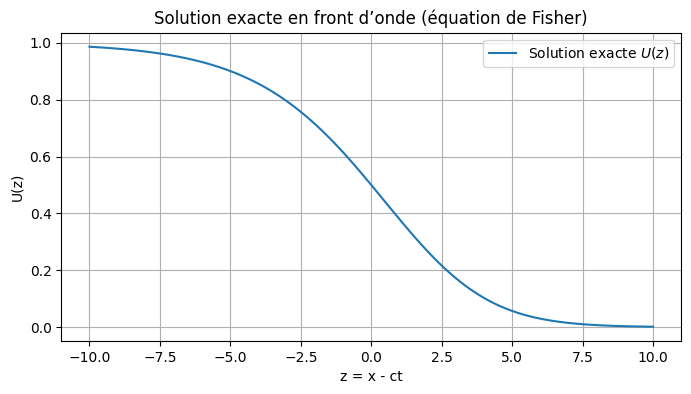

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Profil analytique
def U(z):
    return 1.0 / (1 + (np.sqrt(2) - 1) * np.exp(z / np.sqrt(6)))**2

z = np.linspace(-10, 10, 1000)
u_exact = U(z)

# Affichage
plt.figure(figsize=(8, 4))
plt.plot(z, u_exact, label="Solution exacte $U(z)$")
plt.title("Solution exacte en front d’onde (équation de Fisher)")
plt.xlabel("z = x - ct")
plt.ylabel("U(z)")
plt.grid()
plt.legend()
plt.show()
